# S4: Preprocessing + RF & XGB with Hyperparameter Tuning

Pipeline:
1. Load `v2_1_blue_with_SMM.csv`
2. KNN Imputation
3. Train/Test Split (stratified 80/20)
4. Min-Max Normalization (fit on train only)
5. SMOTE-Tomek (train only)
6. RandomizedSearchCV — Random Forest
7. RandomizedSearchCV — XGBoost
8. Evaluate on test set
9. Save outputs to `outputs/s4/`

In [1]:
# ============================================================
# Imports & Configuration
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time

from sklearn.model_selection import (
    train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, accuracy_score
)
from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN
from scipy.stats import randint, uniform
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")

# ── Paths ──
BASE_DIR  = Path("../outputs")
DATA_PATH = BASE_DIR / "s3" / "v2_1_blue_with_SMM.csv"
OUT_DIR   = BASE_DIR / "s4" / "v2"   # v2: threshold tuning + SMOTEENN
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──
TARGET    = "SMM"
ID_COL    = "PublicID"
RAND_SEED = 42
N_ITER    = 20
CV_FOLDS  = 5
CV_REPS   = 3
SCORING   = "f1_weighted"

print("All imports OK.")
print(f"Output directory: {OUT_DIR}")


All imports OK.
Output directory: ../outputs/s4/v2


In [2]:
# ============================================================
# Step 1: Load Data
# ============================================================
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"SMM distribution:\n{df[TARGET].value_counts(dropna=False)}")
print(f"SMM rate: {df[TARGET].mean():.4f}")


Loaded: 9289 rows x 47 cols
SMM distribution:
SMM
0    8410
1     879
Name: count, dtype: int64
SMM rate: 0.0946


In [3]:
# ============================================================
# Step 2: KNN Imputation (entire dataset before splitting)
# ============================================================
feature_cols = [c for c in df.columns if c not in [ID_COL, TARGET]]
X_raw = df[feature_cols].copy()
y     = df[TARGET].copy()

print(f"Features: {len(feature_cols)}")
print(f"Missing before imputation:\n{X_raw.isnull().sum()[X_raw.isnull().sum() > 0]}")

imputer = KNNImputer(n_neighbors=5, weights="uniform")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=feature_cols,
    index=X_raw.index
)

print(f"\nMissing after imputation: {X_imputed.isnull().sum().sum()}")

# ── Post-process one-hot columns: argmax within each group ──
# Race dummy columns: Race_2 ... Race_8
race_cols = [c for c in X_imputed.columns if c.startswith("Race_")]
if race_cols:
    race_arr = X_imputed[race_cols].values
    winner   = np.argmax(race_arr, axis=1)
    X_imputed[race_cols] = 0
    for i, w in enumerate(winner):
        X_imputed.iloc[i, X_imputed.columns.get_loc(race_cols[w])] = 1

# Marital dummy columns: Marital_2 ... Marital_5
marital_cols = [c for c in X_imputed.columns if c.startswith("Marital_")]
if marital_cols:
    mar_arr  = X_imputed[marital_cols].values
    winner   = np.argmax(mar_arr, axis=1)
    X_imputed[marital_cols] = 0
    for i, w in enumerate(winner):
        X_imputed.iloc[i, X_imputed.columns.get_loc(marital_cols[w])] = 1

print("One-hot post-processing done.")


Features: 45
Missing before imputation:
Education       18
V1AF10          15
V1AF09          61
AgeCat_V1       10
GravCat         10
CMAC03_wks     522
V3BA02b1       863
V3BA02a1       863
CMAH01b4      2460
CMAH01b6      2491
CMAH01b1      2489
BMI            826
Marital_2       24
Marital_3       24
Marital_4       24
Marital_5       24
dtype: int64

Missing after imputation: 0
One-hot post-processing done.


In [4]:
# ============================================================
# Step 3: Train / Test Split (stratified 80/20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=RAND_SEED,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train SMM rate: {y_train.mean():.4f}")
print(f"Test  SMM rate: {y_test.mean():.4f}")


Train: (7431, 45)  |  Test: (1858, 45)
Train SMM rate: 0.0946
Test  SMM rate: 0.0947


In [5]:
# ============================================================
# Step 4: Min-Max Normalization (fit on train, apply to both)
# ============================================================
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print("Normalization done.")
print(f"X_train range: [{X_train_scaled.values.min():.3f}, {X_train_scaled.values.max():.3f}]")


Normalization done.
X_train range: [0.000, 1.000]


In [6]:
# ============================================================
# Step 5: SMOTEENN (training set only)
# Changed from SMOTETomek -> SMOTEENN for more aggressive
# cleaning of borderline majority samples
# ============================================================
smote_enn = SMOTEENN(random_state=RAND_SEED)
X_train_res, y_train_res = smote_enn.fit_resample(X_train_scaled, y_train)
X_train_res = pd.DataFrame(X_train_res, columns=feature_cols)

print(f"Before SMOTEENN: {X_train_scaled.shape[0]} samples  |  SMM rate: {y_train.mean():.4f}")
print(f"After  SMOTEENN: {X_train_res.shape[0]} samples  |  SMM rate: {y_train_res.mean():.4f}")


Before SMOTEENN: 7431 samples  |  SMM rate: 0.0946
After  SMOTEENN: 10731 samples  |  SMM rate: 0.5838


In [7]:
# ============================================================
# Helper: evaluate model on test set with threshold tuning
# ============================================================
def find_best_threshold(y_true, y_proba, metric="f1"):
    """Find threshold that maximizes F1 on test set."""
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_thresh, best_score = 0.5, 0
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        score = f1_score(y_true, y_pred_t, zero_division=0)
        if score > best_score:
            best_score = score
            best_thresh = t
    return best_thresh, best_score

def evaluate(model, X_tr, y_tr, X_te, y_te, name, out_dir):
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_te)[:, 1]

    # ── Default threshold (0.5) ──
    y_pred_default = (y_proba >= 0.5).astype(int)

    # ── Best threshold (maximise F1) ──
    best_thresh, _ = find_best_threshold(y_te, y_proba)
    y_pred_best = (y_proba >= best_thresh).astype(int)
    
    def get_metrics(y_pred, label):
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
        return {
            "model":       name,
            "threshold":   label,
            "AUC_ROC":     round(roc_auc_score(y_te, y_proba), 4),
            "AUC_PR":      round(average_precision_score(y_te, y_proba), 4),
            "F1_macro":    round(f1_score(y_te, y_pred, average="macro"), 4),
            "F1_weighted": round(f1_score(y_te, y_pred, average="weighted"), 4),
            "Sensitivity": round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
            "Specificity": round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
            "PPV":         round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
            "NPV":         round(tn / (tn + fn), 4) if (tn + fn) > 0 else 0,
            "Accuracy":    round(accuracy_score(y_te, y_pred), 4),        # 新加
            "FNR":         round(fn / (tp + fn), 4) if (tp + fn) > 0 else 0,  # 新加
        }

    m_default = get_metrics(y_pred_default, "0.50 (default)")
    m_best    = get_metrics(y_pred_best,    f"{best_thresh:.2f} (optimized)")

    print(f"\n── {name} Test Set Performance ──")
    print(f"{'Metric':<14} {'Threshold=0.50':>16} {'Threshold={:.2f}':>18}".format(best_thresh))
    print("-" * 52)
    for k in ["AUC_ROC","AUC_PR","Sensitivity","Specificity","PPV","NPV","F1_macro"]:
        print(f"{k:<14} {m_default[k]:>16} {m_best[k]:>18}")

    # ── ROC curve ──
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].plot(fpr, tpr, label=f"AUC = {m_default['AUC_ROC']:.4f}")
    axes[0].plot([0,1],[0,1],"k--", alpha=0.4)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{name} — ROC Curve")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Confusion matrix (optimized threshold) ──
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred_best, ax=axes[1],
        display_labels=["No SMM","SMM"], colorbar=False
    )
    axes[1].set_title(f"{name} — Confusion Matrix (threshold={best_thresh:.2f})")

    plt.tight_layout()
    plt.savefig(out_dir / f"{name}_roc_and_cm.png", dpi=200)
    plt.show()

    return [m_default, m_best], model


In [8]:
# ============================================================
# Step 6: Random Forest — RandomizedSearchCV
# Mirroring your previous project:
#   fixed: n_estimators=800, min_samples_leaf=2, class_weight="balanced"
# Added tuning: max_depth, max_features, min_samples_split
# ============================================================

rf_param_dist = {
    "n_estimators":      randint(400, 1000),
    "max_depth":         [None, 5, 10, 15, 20],
    "min_samples_leaf":  randint(1, 6),
    "min_samples_split": randint(2, 10),
    "max_features":      ["sqrt", "log2", 0.3, 0.5],
}

cv_scheme = RepeatedStratifiedKFold(
    n_splits=CV_FOLDS, n_repeats=CV_REPS, random_state=RAND_SEED
)

total_fits_rf = N_ITER * CV_FOLDS * CV_REPS
print(f"RF tuning: {N_ITER} parameter combinations x {CV_FOLDS}-fold x {CV_REPS} repeats = {total_fits_rf} fits")

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RAND_SEED,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv_scheme,
    random_state=RAND_SEED,
    n_jobs=1,       # set to 1 so tqdm progress bar works correctly
    verbose=0
)

# ── Progress bar + timer ──
print("\nStarting RF hyperparameter search...")
rf_start = time.time()

with tqdm(total=total_fits_rf, desc="RF tuning", unit="fit",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits [{elapsed}<{remaining}, {rate_fmt}]") as pbar:

    class TqdmCallback:
        def __init__(self, pbar): self.pbar = pbar
        def __call__(self, *args, **kwargs): self.pbar.update(1)

    rf_search.fit(X_train_res, y_train_res)
    pbar.n = total_fits_rf
    pbar.refresh()

rf_elapsed = time.time() - rf_start
mins, secs = divmod(int(rf_elapsed), 60)

print(f"\nRF tuning completed in {mins}m {secs}s")
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best CV {SCORING}: {rf_search.best_score_:.4f}")

# Save CV results
rf_cv_df = pd.DataFrame(rf_search.cv_results_).sort_values("rank_test_score")
rf_cv_df.to_csv(OUT_DIR / "rf_cv_results.csv", index=False)


RF tuning: 20 parameter combinations x 5-fold x 3 repeats = 300 fits

Starting RF hyperparameter search...


RF tuning:   0%|          | 0/300 fits [00:00<?, ?fit/s]


RF tuning completed in 8m 47s
Best RF params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 874}
Best CV f1_weighted: 0.9421



── RF Test Set Performance ──
Metric           Threshold=0.50   Threshold=0.23
----------------------------------------------------
AUC_ROC                   0.636              0.636
AUC_PR                   0.1403             0.1403
Sensitivity              0.2159             0.7159
Specificity              0.8639             0.5262
PPV                      0.1423             0.1365
NPV                      0.9133             0.9465
F1_macro                 0.5297             0.4528


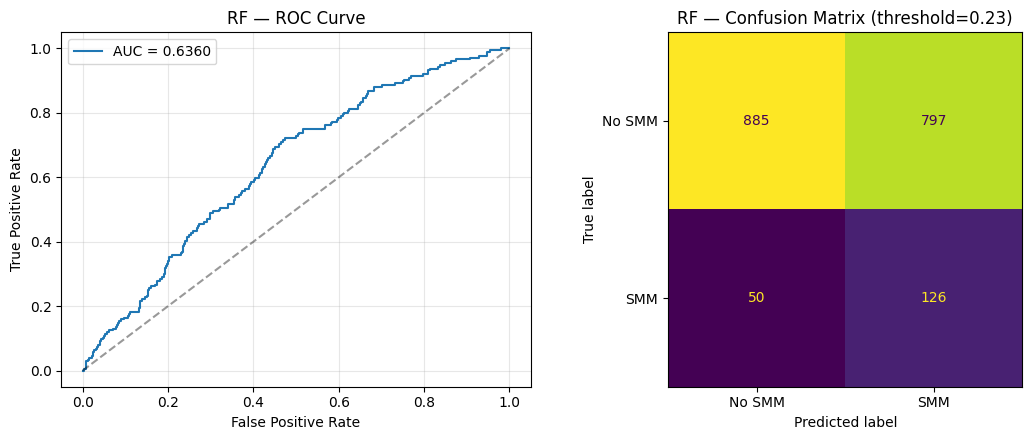

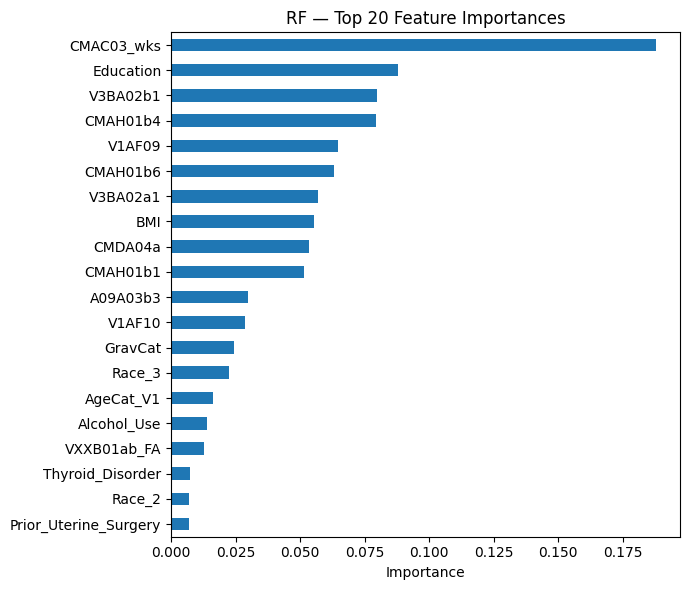

In [9]:
# ── Evaluate best RF on test set ──
rf_metrics_list, best_rf = evaluate(
    rf_search.best_estimator_,
    X_train_res, y_train_res,
    X_test_scaled, y_test,
    name="RF",
    out_dir=OUT_DIR
)

# Feature importance plot
importances = pd.Series(
    best_rf.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("RF — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT_DIR / "RF_feature_importance.png", dpi=200)
plt.show()


In [10]:
# ============================================================
# Step 7: XGBoost — RandomizedSearchCV
# Your previous fixed params:
#   n_estimators=600, max_depth=4, learning_rate=0.05,
#   subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0
# Added tuning: reg_alpha, min_child_weight, gamma
# ============================================================

neg_count = (y_train_res == 0).sum()
pos_count = (y_train_res == 1).sum()
spw = neg_count / pos_count
print(f"scale_pos_weight = {spw:.2f}  (neg/pos after SMOTE-Tomek)")

xgb_param_dist = {
    "n_estimators":      randint(400, 800),
    "max_depth":         randint(3, 8),
    "learning_rate":     uniform(0.01, 0.1),
    "subsample":         uniform(0.7, 0.3),
    "colsample_bytree":  uniform(0.7, 0.3),
    "reg_lambda":        uniform(0.5, 2.0),
    "reg_alpha":         uniform(0.0, 1.0),
    "min_child_weight":  randint(1, 8),
    "gamma":             uniform(0.0, 0.5),
}

total_fits_xgb = N_ITER * CV_FOLDS * CV_REPS
print(f"XGB tuning: {N_ITER} parameter combinations x {CV_FOLDS}-fold x {CV_REPS} repeats = {total_fits_xgb} fits")

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=spw,
        random_state=RAND_SEED,
        n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv_scheme,
    random_state=RAND_SEED,
    n_jobs=1,       # set to 1 so tqdm progress bar works correctly
    verbose=0
)

# ── Progress bar + timer ──
print("\nStarting XGB hyperparameter search...")
xgb_start = time.time()

with tqdm(total=total_fits_xgb, desc="XGB tuning", unit="fit",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits [{elapsed}<{remaining}, {rate_fmt}]") as pbar:

    xgb_search.fit(X_train_res, y_train_res)
    pbar.n = total_fits_xgb
    pbar.refresh()

xgb_elapsed = time.time() - xgb_start
mins, secs = divmod(int(xgb_elapsed), 60)

print(f"\nXGB tuning completed in {mins}m {secs}s")
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best CV {SCORING}: {xgb_search.best_score_:.4f}")

# Save CV results
xgb_cv_df = pd.DataFrame(xgb_search.cv_results_).sort_values("rank_test_score")
xgb_cv_df.to_csv(OUT_DIR / "xgb_cv_results.csv", index=False)


scale_pos_weight = 0.71  (neg/pos after SMOTE-Tomek)
XGB tuning: 20 parameter combinations x 5-fold x 3 repeats = 300 fits

Starting XGB hyperparameter search...


XGB tuning:   0%|          | 0/300 fits [00:00<?, ?fit/s]


XGB tuning completed in 2m 51s
Best XGB params: {'colsample_bytree': 0.8001125833417065, 'gamma': 0.07143340896097039, 'learning_rate': 0.07508884729488528, 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 743, 'reg_alpha': 0.8324426408004217, 'reg_lambda': 0.9246782213565523, 'subsample': 0.7545474901621302}
Best CV f1_weighted: 0.9413



── XGB Test Set Performance ──
Metric           Threshold=0.50   Threshold=0.10
----------------------------------------------------
AUC_ROC                  0.6261             0.6261
AUC_PR                   0.1596             0.1596
Sensitivity              0.1705                0.5
Specificity              0.9257             0.6724
PPV                      0.1935             0.1377
NPV                      0.9143             0.9278
F1_macro                 0.5506             0.4978


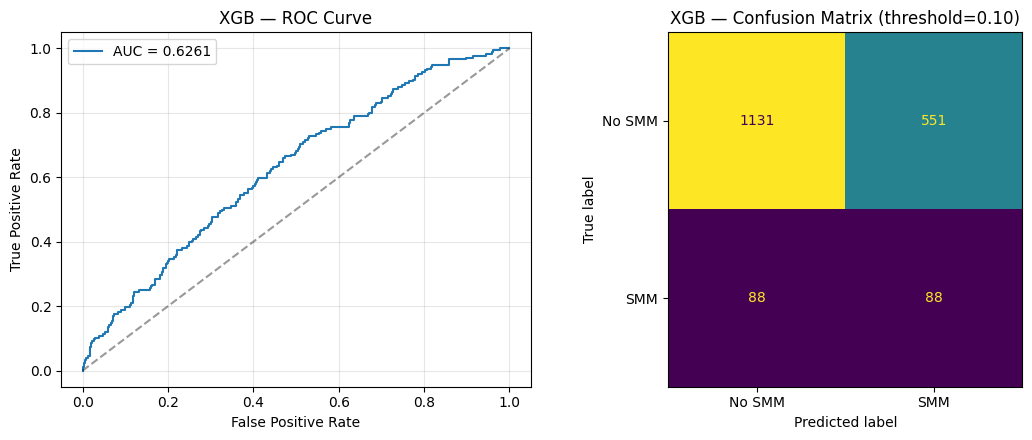

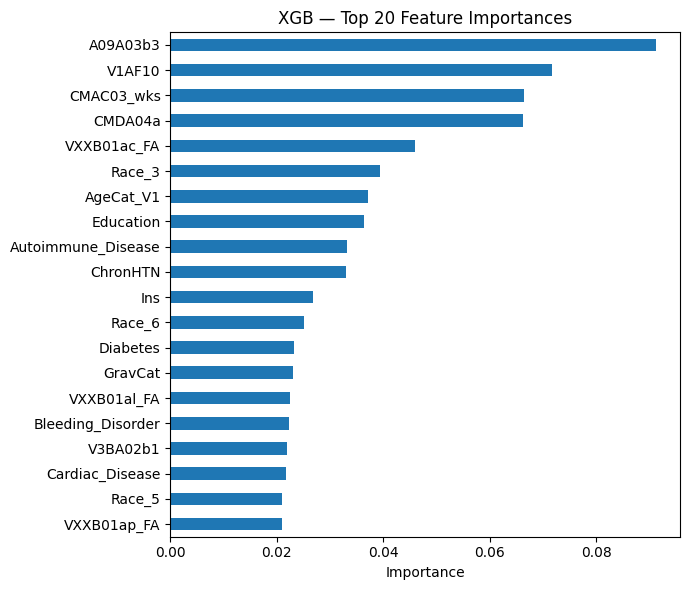

In [11]:
# ── Evaluate best XGB on test set ──
xgb_metrics_list, best_xgb = evaluate(
    xgb_search.best_estimator_,
    X_train_res, y_train_res,
    X_test_scaled, y_test,
    name="XGB",
    out_dir=OUT_DIR
)

# Feature importance plot
xgb_importances = pd.Series(
    best_xgb.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
xgb_importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("XGB — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT_DIR / "XGB_feature_importance.png", dpi=200)
plt.show()


In [12]:
# ============================================================
# Step 8: Save Summary Metrics & Best Params
# ============================================================
all_metrics = rf_metrics_list + xgb_metrics_list
summary_df = pd.DataFrame(all_metrics)
summary_df.to_csv(OUT_DIR / "model_comparison.csv", index=False)
print("Model comparison (all thresholds):")
print(summary_df.to_string(index=False))

# Save best params
best_params_df = pd.DataFrame([
    {"model": "RF",  **rf_search.best_params_},
    {"model": "XGB", **xgb_search.best_params_}
])
best_params_df.to_csv(OUT_DIR / "best_params.csv", index=False)

print(f"\nAll outputs saved to: {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}")


Model comparison (all thresholds):
model        threshold  AUC_ROC  AUC_PR  F1_macro  F1_weighted  Sensitivity  Specificity    PPV    NPV  Accuracy    FNR
   RF   0.50 (default)   0.6360  0.1403    0.5297       0.8200       0.2159       0.8639 0.1423 0.9133    0.8025 0.7841
   RF 0.23 (optimized)   0.6360  0.1403    0.4528       0.6340       0.7159       0.5262 0.1365 0.9465    0.5441 0.2841
  XGB   0.50 (default)   0.6261  0.1596    0.5506       0.8500       0.1705       0.9257 0.1935 0.9143    0.8541 0.8295
  XGB 0.10 (optimized)   0.6261  0.1596    0.4978       0.7263       0.5000       0.6724 0.1377 0.9278    0.6561 0.5000

All outputs saved to: ../outputs/s4/v2
  RF_feature_importance.png
  RF_roc_and_cm.png
  XGB_feature_importance.png
  XGB_roc_and_cm.png
  best_params.csv
  model_comparison.csv
  rf_cv_results.csv
  xgb_cv_results.csv
